# 10 — Pretraining: Actually Training the Model

**Lecture goal:** define a loss function that measures how wrong the model's predictions are, build the training loop (the three-line core: `zero_grad`, `backward`, `step`), and watch our small model go from producing gibberish to producing recognizably-corpus-like text on `the-verdict.txt`.

## Setup: rebuild the model and data pipeline from notebooks 08/09

Nothing new here — the exact same classes and config as before.

In [1]:
import torch
import torch.nn as nn
import tiktoken
from torch.utils.data import Dataset, DataLoader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        batch_size, num_tokens, d_in = x.shape
        queries = self.W_query(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = self.W_key(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values = self.W_value(x).view(batch_size, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / self.head_dim ** 0.5, dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.d_out)
        return self.out_proj(context_vectors)


class LayerNorm(nn.Module):
    def __init__(self, embedding_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized + self.shift


class FeedForward(nn.Module):
    def __init__(self, embedding_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim), nn.GELU(), nn.Linear(4 * embedding_dim, embedding_dim)
        )

    def forward(self, x):
        return self.layers(x)


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MultiHeadAttention(
            d_in=cfg["embedding_dim"], d_out=cfg["embedding_dim"], context_length=cfg["context_length"],
            dropout=cfg["dropout_rate"], num_heads=cfg["num_heads"], qkv_bias=cfg["qkv_bias"],
        )
        self.feed_forward = FeedForward(cfg["embedding_dim"])
        self.norm1 = LayerNorm(cfg["embedding_dim"])
        self.norm2 = LayerNorm(cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.dropout(x)
        x = x + shortcut
        shortcut = x
        x = self.norm2(x)
        x = self.feed_forward(x)
        x = self.dropout(x)
        x = x + shortcut
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["embedding_dim"])
        self.position_embedding = nn.Embedding(cfg["context_length"], cfg["embedding_dim"])
        self.dropout = nn.Dropout(cfg["dropout_rate"])
        self.transformer_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["num_layers"])])
        self.final_norm = LayerNorm(cfg["embedding_dim"])
        self.out_head = nn.Linear(cfg["embedding_dim"], cfg["vocab_size"], bias=False)

    def forward(self, token_ids):
        batch_size, num_tokens = token_ids.shape
        token_embeds = self.token_embedding(token_ids)
        positions = torch.arange(num_tokens, device=token_ids.device)
        pos_embeds = self.position_embedding(positions)
        x = self.dropout(token_embeds + pos_embeds)
        x = self.transformer_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)


class GPTDatasetV1(Dataset):
    def __init__(self, text, tokenizer, context_length, stride):
        self.input_ids = []
        self.target_ids = []
        token_ids = tokenizer.encode(text)
        for start in range(0, len(token_ids) - context_length, stride):
            self.input_ids.append(torch.tensor(token_ids[start : start + context_length]))
            self.target_ids.append(torch.tensor(token_ids[start + 1 : start + context_length + 1]))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(text, batch_size, context_length, stride, shuffle, drop_last):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDatasetV1(text, tokenizer, context_length, stride)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)


def generate(model, token_ids, max_new_tokens, context_size, temperature=1.0, top_k=None):
    for _ in range(max_new_tokens):
        idx_condition = token_ids[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_condition)
        last_logits = logits[:, -1, :]
        if top_k is not None:
            top_k_values, _ = torch.topk(last_logits, top_k)
            min_value = top_k_values[:, -1]
            last_logits = torch.where(
                last_logits < min_value.unsqueeze(-1), torch.tensor(-torch.inf), last_logits
            )
        if temperature > 0.0:
            probabilities = torch.softmax(last_logits / temperature, dim=-1)
            next_token_id = torch.multinomial(probabilities, num_samples=1)
        else:
            next_token_id = torch.argmax(last_logits, dim=-1, keepdim=True)
        token_ids = torch.cat([token_ids, next_token_id], dim=1)
    return token_ids


GPT_CONFIG_SMALL = {
    "vocab_size": 50257,
    "context_length": 128,
    "embedding_dim": 256,
    "num_heads": 4,
    "num_layers": 4,
    "dropout_rate": 0.1,
    "qkv_bias": False,
}

tokenizer = tiktoken.get_encoding("gpt2")
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Setup complete.")

Setup complete.


## Step 1: A loss function — measuring "how wrong"

We need a single number that says how far off the model's predictions are from the truth, which we can then work to minimize. Recall from notebook 08: for every position in a sequence, the model outputs `logits` — one raw score per vocabulary token — which softmax (notebook 05) turns into a probability distribution over "what comes next."

We *know* the true next token (it's right there in our training text). A good loss function should be small when the model assigns **high probability to the actual, correct next token**, and large when it assigns that correct token low probability. This is exactly **cross-entropy loss**:

```
loss = -log(probability the model assigned to the correct token)
```

Why the negative log? Probabilities range from 0 to 1. `log` of a number close to 1 is close to 0 (small loss — the model was confident and correct); `log` of a number close to 0 is a large negative number, so the *negative* log becomes a large *positive* loss (the model was confident and *wrong*, or just very unsure) — exactly the "how wrong" signal we want to minimize.

PyTorch's `F.cross_entropy` combines the softmax and the negative-log-probability step into one numerically stable function, so we hand it raw logits directly (never manually apply softmax first).

In [2]:
import torch.nn.functional as F

# Grab one real batch to see the shapes involved.
loader = create_dataloader_v1(raw_text, batch_size=2, context_length=GPT_CONFIG_SMALL["context_length"], stride=GPT_CONFIG_SMALL["context_length"], shuffle=False, drop_last=True)
inputs, targets = next(iter(loader))

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_SMALL)

logits = model(inputs)
print("logits shape: ", logits.shape)   # (batch, num_tokens, vocab_size)
print("targets shape:", targets.shape)  # (batch, num_tokens)

# F.cross_entropy expects a 2-D input of shape (N, num_classes) and a 1-D target of shape (N,),
# so we flatten the batch and position dimensions together: every (example, position) pair
# becomes one independent classification problem, "which of 50257 tokens comes next here?"
loss = F.cross_entropy(logits.flatten(0, 1), targets.flatten())
print("Loss (untrained model):", loss.item())

logits shape:  torch.Size([2, 128, 50257])
targets shape: torch.Size([2, 128])
Loss (untrained model): 10.996175765991211


### Perplexity: a more interpretable version of the same number

`exp(loss)` is called **perplexity**. It has a nice intuitive reading: a perplexity of `P` means the model is, on average, about as uncertain as if it were guessing uniformly at random among `P` options. Our untrained model's perplexity should be close to the vocabulary size itself — i.e., about as confused as a model that hasn't learned anything at all *should* be.

In [3]:
perplexity = torch.exp(loss)
print("Perplexity:", perplexity.item())
print("Vocabulary size, for comparison:", GPT_CONFIG_SMALL["vocab_size"])

Perplexity: 59645.60546875
Vocabulary size, for comparison: 50257


## Step 2: Train/validation split

If we only ever measure loss on the exact text the model is training on, we can't tell the difference between "the model learned general patterns of English" and "the model just memorized these specific sentences." We hold out a **validation set** — text the model never trains on — and watch loss on *that* to judge real progress. We'll use a simple 90/10 split of `the-verdict.txt`.

In [4]:
split_idx = int(0.9 * len(raw_text))
train_text = raw_text[:split_idx]
val_text = raw_text[split_idx:]

train_loader = create_dataloader_v1(
    train_text, batch_size=2, context_length=GPT_CONFIG_SMALL["context_length"],
    stride=GPT_CONFIG_SMALL["context_length"], shuffle=True, drop_last=True,
)
val_loader = create_dataloader_v1(
    val_text, batch_size=2, context_length=GPT_CONFIG_SMALL["context_length"],
    stride=GPT_CONFIG_SMALL["context_length"], shuffle=False, drop_last=False,
)

print("Training batches:  ", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches:   18
Validation batches: 2


This corpus is tiny (one short story), so we only get a handful of batches either way — worth keeping in mind when we look at the results later: there simply isn't enough data here for the model to learn general English, only to partially memorize this one story. That's a real limitation we'll address in notebook 11 by loading a model that *was* trained on a huge corpus.

Two small helper functions: loss for a single batch, and average loss across (a subset of) a whole loader.

In [5]:
def calc_loss_batch(input_batch, target_batch, model):
    logits = model(input_batch)
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        with torch.no_grad():
            loss = calc_loss_batch(input_batch, target_batch, model)
        total_loss += loss.item()

    return total_loss / num_batches

## Step 3: The training loop

This is where the model actually learns. Three ideas come together:

- **`loss.backward()`** — PyTorch's autograd (first mentioned in notebook 07) walks backward through every operation that produced `loss`, computing the *gradient* of the loss with respect to every learnable parameter: "if I nudged this particular number up slightly, would the loss go up or down, and by how much?"
- **An optimizer** (`torch.optim.AdamW`) uses those gradients to actually update the parameters — nudging each one a small step in the direction that *reduces* the loss. "Adam" adapts the step size per parameter based on the recent history of its gradients (parameters that have been getting consistent gradient signals take bigger, more confident steps; noisy ones take smaller, more cautious steps) — in practice, it converges faster and more reliably than plain fixed-step gradient descent. "W" adds weight decay, a mild pull toward smaller weight values that helps prevent overfitting.
- **`optimizer.zero_grad()`** — PyTorch *accumulates* gradients by default (adds new ones on top of old) rather than replacing them, since that's occasionally useful for advanced training tricks. For a standard loop like ours, we need to explicitly clear old gradients before computing new ones each step, or they'd incorrectly pile up across batches.

The repeating core of every training step, in order:

```python
optimizer.zero_grad()   # clear old gradients
loss.backward()         # compute new gradients for this batch
optimizer.step()        # update every parameter using those gradients
```

We wrap this in a loop over the data, run it for several **epochs** (full passes over the training data), and periodically check loss on both train and validation sets, plus generate a short sample so we can watch progress qualitatively as well as numerically.

In [6]:
def train_model_simple(model, train_loader, val_loader, optimizer, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses = [], []
    global_step = 0

    for epoch in range(num_epochs):
        model.train()  # re-enable dropout for training

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model)
            loss.backward()
            optimizer.step()
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                train_loss = calc_loss_loader(train_loader, model, num_batches=eval_iter)
                val_loss = calc_loss_loader(val_loader, model, num_batches=eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Epoch {epoch + 1} (step {global_step}): train loss {train_loss:.3f}, val loss {val_loss:.3f}")
                model.train()

        # End of epoch: generate a short sample so we can see qualitative progress too.
        model.eval()
        encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0)
        with torch.no_grad():
            sample_ids = generate(model, encoded, max_new_tokens=25, context_size=GPT_CONFIG_SMALL["context_length"], temperature=0.0)
        print("  Sample:", repr(tokenizer.decode(sample_ids.squeeze(0).tolist())))
        model.train()

    return train_losses, val_losses

In [7]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_SMALL)
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses = train_model_simple(
    model, train_loader, val_loader, optimizer,
    num_epochs=num_epochs, eval_freq=5, eval_iter=3,
    start_context="Every effort moves you", tokenizer=tokenizer,
)

Epoch 1 (step 5): train loss 10.267, val loss 10.490


Epoch 1 (step 10): train loss 9.666, val loss 9.743


Epoch 1 (step 15): train loss 8.985, val loss 9.069


  Sample: 'Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,'


Epoch 2 (step 20): train loss 8.289, val loss 8.441


...

  Sample: 'Every effort moves you, I had been a little of the picture--I of the fact of the.\n\n\n"I had been of'


Epoch 10 (step 165): train loss 3.760, val loss 6.109


Epoch 10 (step 170): train loss 3.613, val loss 6.093


Epoch 10 (step 175): train loss 3.335, val loss 6.084


Epoch 10 (step 180): train loss 3.363, val loss 6.082
  Sample: 'Every effort moves you of that he had a little of the fact, a deprec.\n\n"--as I was, I had been'


Watch the samples printed after each epoch: they start as pure noise and, within a few epochs, start reproducing actual phrases and word combinations from `the-verdict.txt` — concrete, visible evidence the training loop is working.

Let's plot the loss curves to see the numeric picture alongside the qualitative one.

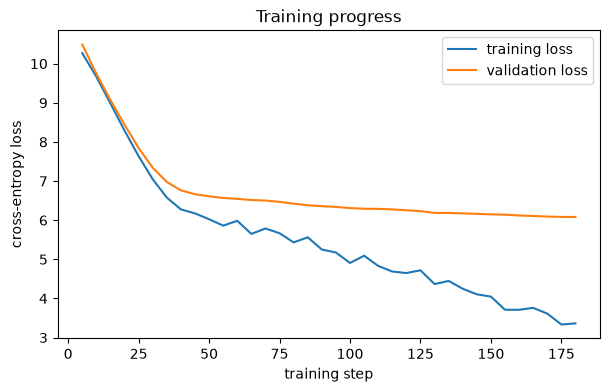

In [8]:
import matplotlib.pyplot as plt

eval_steps = list(range(5, 5 * (len(train_losses) + 1), 5))

plt.figure(figsize=(7, 4))
plt.plot(eval_steps, train_losses, label="training loss")
plt.plot(eval_steps, val_losses, label="validation loss")
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.title("Training progress")
plt.show()

If you see training loss keep dropping while validation loss flattens out or starts climbing back up, that's **overfitting**: with a text this short, the model has enough capacity to essentially memorize it rather than learn generalizable patterns of English. This is expected and, honestly, the correct outcome given how little data we gave it — real GPT-2 was trained on roughly 40GB of internet text, about six orders of magnitude more than our one short story. This is exactly why notebook 11 switches to loading OpenAI's actual pretrained weights instead of continuing to train our own from scratch.

## Generating text with the trained model

Let's compare generation before-training-quality (pure noise, notebook 09) against what our small amount of training produced.

In [9]:
model.eval()
start_context = "Every effort moves you"
encoded = torch.tensor(tokenizer.encode(start_context)).unsqueeze(0)

torch.manual_seed(123)
output_ids = generate(
    model, encoded, max_new_tokens=30, context_size=GPT_CONFIG_SMALL["context_length"],
    temperature=0.8, top_k=25,
)
print(repr(tokenizer.decode(output_ids.squeeze(0).tolist())))

'Every effort moves you, I had been a. And. Gisburn!\n\n\nI was me--I was that he had know--I: " "'


## Recap

- **Cross-entropy loss** measures how much probability the model assigned to the *actual* correct next token — low loss means confident, correct predictions. `exp(loss)` (**perplexity**) gives an intuitive "effectively choosing among how many options" reading.
- A **train/validation split** lets us distinguish real learning from memorization; watching both loss curves reveals overfitting when it happens.
- The training loop's core is three lines: `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()` — clear old gradients, compute new ones via autograd, apply an update via the optimizer (`AdamW`).
- With a tiny amount of training data, the model can visibly start reproducing the training text, but can't learn general language ability — that requires far more data and compute than we have here.

### What's next

We've now built and trained every piece of a GPT model ourselves, end to end. In notebook 11, instead of training from scratch, we'll load OpenAI's actual pretrained GPT-2 (124M) weights into our own `GPTModel` implementation, and see the dramatic difference real-scale pretraining makes on the exact same architecture and `generate()` function.